# NB-02 | Exploratory Data Analysis

**Project:** GA4 Google Merchandise Store — Marketing Propensity Model  
**Dataset:** `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`  
**Date range:** 2020-11-01 → 2021-01-31 (92 days)  
**Inputs:** `data/raw/sessions.csv`, `data/raw/events_sample.csv`  
**Purpose:** Understand distributions, validate data quality, and produce charts for the final report.

---

## Notebook outline
1. Setup & data loading  
2. Dataset overview  
3. Event taxonomy  
4. Session-level distributions  
5. Traffic source & device breakdown  
6. Geographic distribution  
7. Purchase funnel drop-off  
8. Class imbalance (conversion rate)  
9. Correlation heatmap  
10. EDA summary & notes for NB-03

---
## 1. Setup & data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ── Global plot style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': False,           # Erase the grid lines
    'axes.edgecolor': '#808080',  # Set remaining spines (bottom/left) to grey
    'axes.linewidth': 0.8,        # Optional: slightly thinner spines for minimalism
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

BLUE   = '#2563EB'
ORANGE = '#EA580C'
GREEN  = '#16A34A'
GRAY   = '#6B7280'
PALETTE = [BLUE, ORANGE, GREEN, '#7C3AED', '#DB2777', '#0891B2']

print('Libraries loaded.')

Libraries loaded.


In [2]:
# ── Load data ──────────────────────────────────────────────────────────────────
# Adjust paths if your folder layout differs.
sessions   = pd.read_csv('data/raw/sessions.csv',      dtype={'session_id': 'Int64'})
events_raw = pd.read_csv('data/raw/events_sample.csv', dtype={'session_id': 'Int64',
                                                                   'event_timestamp': 'Int64'})

print(f'sessions   : {sessions.shape[0]:,} rows × {sessions.shape[1]} cols')
print(f'events_raw : {events_raw.shape[0]:,} rows × {events_raw.shape[1]} cols')

sessions   : 360,129 rows × 13 cols
events_raw : 2,194,458 rows × 10 cols


### data loading (360,129 / 2,194,458 rows)
 
> Both files loaded cleanly with no parsing errors. The session table (360,129 rows) is the model input; the event table (2,194,458 rows) is used only for funnel and EDA analysis. The 6:1 row ratio reflects the fact that every session contains multiple events — consistent with a median of 5 events per session seen in the descriptive stats below.

---
## 2. Dataset overview

In [3]:
# ── sessions.csv overview ──────────────────────────────────────────────────────
print('=== sessions.csv — dtypes & nulls ===')
overview = pd.DataFrame({
    'dtype':    sessions.dtypes,
    'non_null': sessions.notna().sum(),
    'null_pct': (sessions.isna().mean() * 100).round(2),
    'n_unique': sessions.nunique(),
})
print(overview.to_string())

=== sessions.csv — dtypes & nulls ===
                        dtype  non_null  null_pct  n_unique
user_pseudo_id        float64    360129       0.0    270154
session_id              Int64    360129       0.0    349545
converted               int64    360129       0.0         2
total_events            int64    360129       0.0       423
page_views              int64    360129       0.0       159
items_viewed            int64    360129       0.0       123
add_to_cart             int64    360129       0.0        62
checkout_starts         int64    360129       0.0        36
session_duration_sec  float64    360129       0.0     73234
device                 object    360129       0.0         3
country                object    360129       0.0       109
traffic_medium         object    360129       0.0         6
traffic_source         object    360129       0.0         5


### sessions.csv dtypes & nulls
 
> **Zero null values across all 13 columns** — the SQL aggregation query handled this correctly; `MAX()` over session-constant fields ensured no nulls propagate from sparse rows. Two columns warrant a note: `user_pseudo_id` is stored as `float64` rather than string (a BigQuery export artefact — the ID is a hashed numeric), and `traffic_source` has only 5 unique values despite being a free-text field, suggesting the dataset's obfuscation has collapsed many source strings into placeholder categories.

In [4]:
# ── events_sample.csv overview ────────────────────────────────────────────────
print('=== events_sample.csv — dtypes & nulls ===')
overview_ev = pd.DataFrame({
    'dtype':    events_raw.dtypes,
    'non_null': events_raw.notna().sum(),
    'null_pct': (events_raw.isna().mean() * 100).round(2),
    'n_unique': events_raw.nunique(),
})
print(overview_ev.to_string())

=== events_sample.csv — dtypes & nulls ===
                   dtype  non_null  null_pct  n_unique
user_pseudo_id   float64   2194458      0.00    269989
event_date         int64   2194458      0.00        92
event_name        object   2194458      0.00         6
event_timestamp    Int64   2194458      0.00   1684445
session_id         Int64   2194458      0.00    349281
page_location     object   2194458      0.00      2516
session_engaged  float64   1839367     16.18         2
device_category   object   2194458      0.00         3
country           object   2194458      0.00       109
traffic_medium    object   2194458      0.00         6


### events_sample.csv dtypes & nulls
 
> The only column with missing values is `session_engaged` — **16.18% null**. This is expected: the `session_engaged` parameter is only attached to `session_start` events, not to `page_view`, `view_item`, or other event types. Since we do not use this column in the session-level model features (engagement is captured indirectly through `session_duration_sec` and event counts), the nulls require no imputation.

In [5]:
# ── Numeric summary for sessions ──────────────────────────────────────────────
sessions.describe(percentiles=[.25, .5, .75, .95, .99]).round(2)

,user_pseudo_id,session_id,converted,total_events,page_views,items_viewed,add_to_cart,checkout_starts,session_duration_sec
count,3.601290e+05,360129.0,360129.00,360129.00,360129.00,360129.00,360129.00,360129.00,360129.00
mean,2.522630e+08,4993448813.65,0.01,11.93,3.75,1.07,0.16,0.11,203.33
std,1.149292e+09,2886952255.07,0.12,26.47,9.01,4.75,1.34,0.85,936.32
min,1.000300e+06,1205.0,0.00,1.00,0.00,0.00,0.00,0.00,0.00
25%,5.950364e+06,2496339027.0,0.00,4.00,1.00,0.00,0.00,0.00,4.19
50%,2.265732e+07,4988996569.0,0.00,5.00,2.00,0.00,0.00,0.00,13.98
75%,6.149694e+07,7492214222.0,0.00,9.00,3.00,0.00,0.00,0.00,110.19
95%,9.520823e+07,9495010708.200001,0.00,39.00,13.00,5.00,0.00,0.00,1192.95
99%,7.385163e+09,9896887816.959999,1.00,125.00,37.00,21.00,5.00,3.00,2456.47
max,9.994023e+09,9999997129.0,1.00,1007.00,566.00,319.00,74.00,54.00,402477.09


### describe() table
 
> Key takeaways from the descriptive statistics:
 
- **Median session** has 5 total events, 2 page views, 0 items viewed, and lasts ~14 seconds — confirming that the majority of sessions are brief, low-intent visits.
- **The 75th percentile** of `add_to_cart` and `checkout_starts` is 0, meaning at least three-quarters of all sessions never reach the product engagement stage.
- **`session_duration_sec`** has a mean of 203 seconds but a max of 402,477 seconds (~4.6 days) — a clear outlier indicating bot traffic or an unclosed browser tab. The 99th percentile (2,456 sec ≈ 41 min) will be used as the cap in NB-03.

---
## 3. Event taxonomy

What event types are present in `events_sample.csv`, in what volumes, and by how many unique users?

In [6]:
# ── Event counts by type ───────────────────────────────────────────────────────
event_counts = (
    events_raw
    .groupby('event_name')
    .agg(
        event_count  = ('event_name', 'size'),
        unique_users = ('user_pseudo_id', 'nunique'),
    )
    .sort_values('event_count', ascending=False)
    .reset_index()
)
event_counts['events_per_user'] = (
    event_counts['event_count'] / event_counts['unique_users']
).round(2)

print(event_counts.to_string(index=False))

    event_name  event_count  unique_users  events_per_user
     page_view      1350428        269792             5.01
     view_item       386068         61252             6.30
 session_start       354970        267116             1.33
   add_to_cart        58543         12545             4.67
begin_checkout        38757          9715             3.99
      purchase         5692          4419             1.29


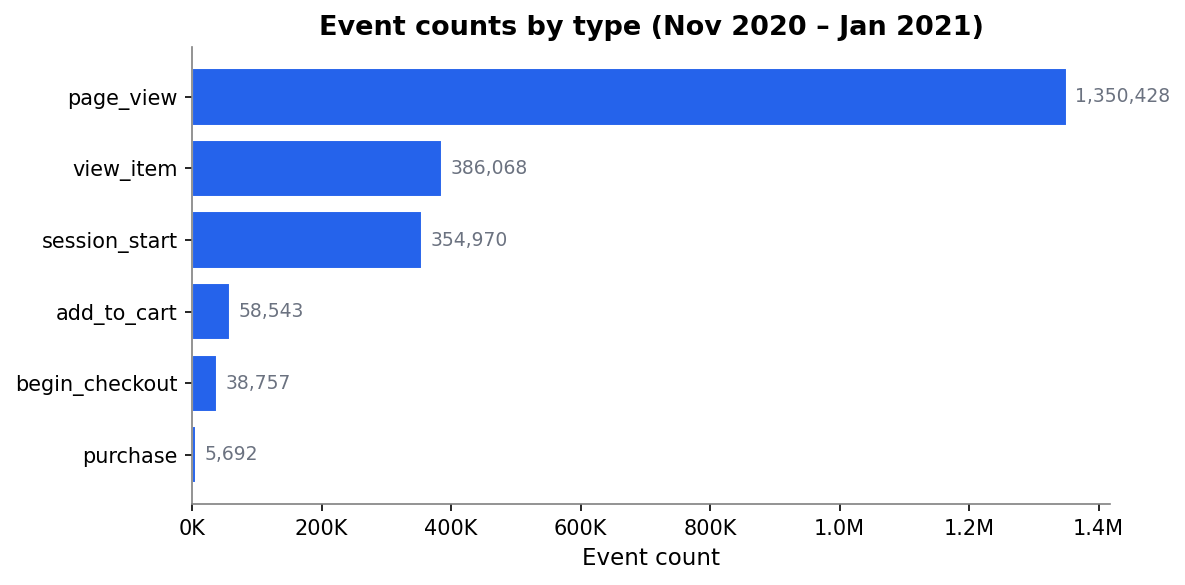

In [7]:
# ── Chart: event counts ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.barh(
    event_counts['event_name'],
    event_counts['event_count'],
    color=BLUE,
    edgecolor='white',
    height=0.8,
)
ax.invert_yaxis()

for bar, val in zip(bars, event_counts['event_count']):
    ax.text(val + event_counts['event_count'].max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,.0f}', va='center', fontsize=9, color=GRAY)

ax.set_xlabel('Event count')
ax.set_title('Event counts by type (Nov 2020 – Jan 2021)', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))
plt.tight_layout()
plt.savefig('reports/fig_event_taxonomy.png', bbox_inches='tight')
plt.show()

### Event counts table
 
> The funnel structure is visible directly in the event counts: **1.35M page views** collapse to **386K item views**, **58K add-to-carts**, and just **5,692 purchases** — a drop of over 99% from top to bottom. Notably, `session_start` (354,970) is slightly lower than unique sessions in `sessions.csv` (360,129); the difference is expected since a session can exist in the aggregated table without a recorded `session_start` event if the start event fell outside our filter window.

---
## 4. Session-level distributions

Understand the shape of the key numeric features we will use in the model.

In [8]:
# ── Helper: log-scale histogram ────────────────────────────────────────────────
def log_hist(ax, series, title, xlabel, color=BLUE, bins=60):
    """Plot histogram of log1p-transformed series with original-scale x-ticks."""
    log_vals = np.log1p(series.dropna())
    ax.hist(log_vals, bins=bins, color=color, edgecolor='white', linewidth=0.4)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(f'{xlabel} (log scale)')
    ax.set_ylabel('Sessions')
    # Annotate median
    med = series.median()
    ax.axvline(np.log1p(med), color=ORANGE, linestyle='--', linewidth=1.5,
               label=f'Median = {med:,.1f}')
    ax.legend(fontsize=8)

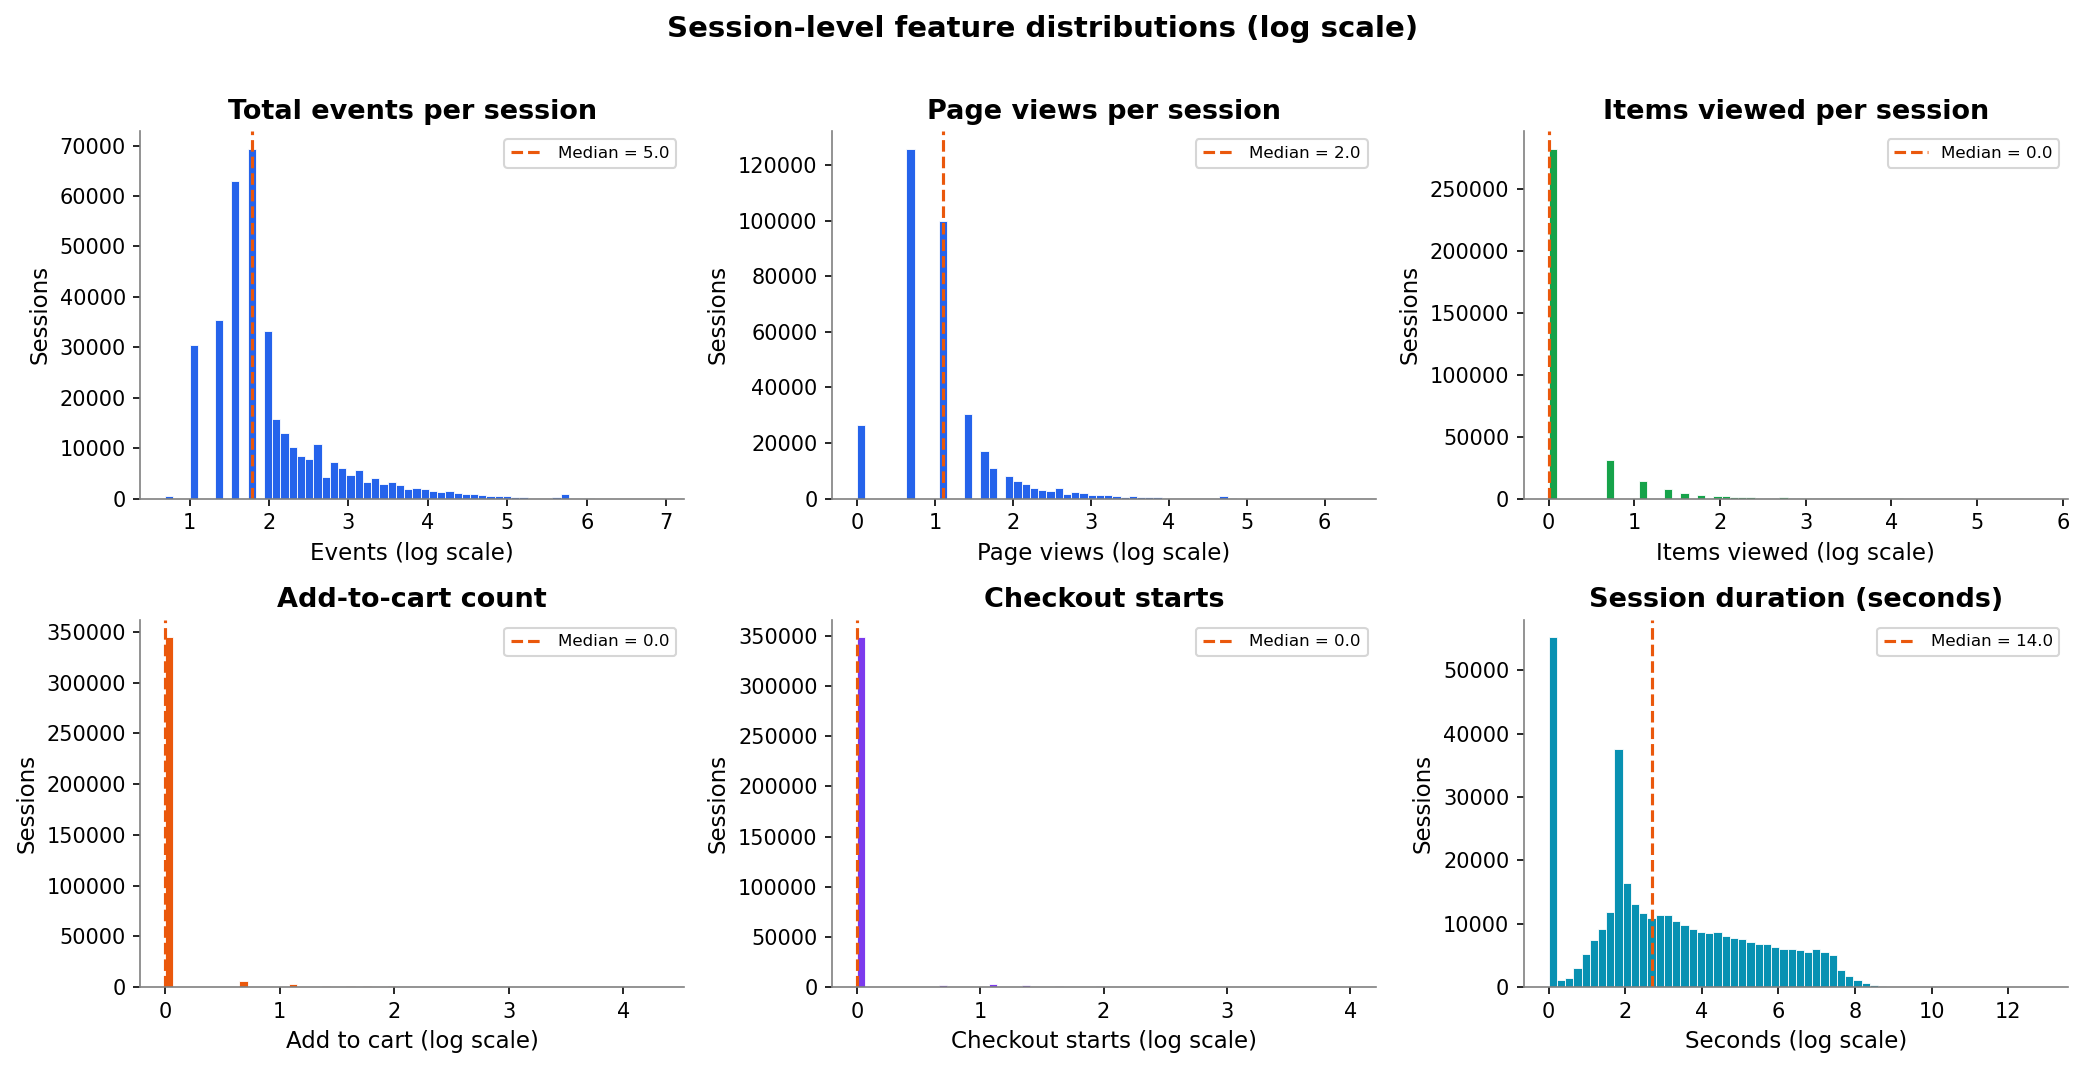


Note: Most sessions are short, low-engagement browse sessions.
Distributions are heavily right-skewed — log transformation will help the LR baseline.


In [9]:
# ── 2×3 distribution grid ─────────────────────────────────────────────────────
num_cols = [
    ('total_events',          'Total events per session',    'Events'),
    ('page_views',            'Page views per session',      'Page views'),
    ('items_viewed',          'Items viewed per session',    'Items viewed'),
    ('add_to_cart',           'Add-to-cart count',           'Add to cart'),
    ('checkout_starts',       'Checkout starts',             'Checkout starts'),
    ('session_duration_sec',  'Session duration (seconds)',  'Seconds'),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
colors = [BLUE, BLUE, GREEN, ORANGE, '#7C3AED', '#0891B2']

for ax, (col, title, xlabel), color in zip(axes.flat, num_cols, colors):
    log_hist(ax, sessions[col], title, xlabel, color=color)

fig.suptitle('Session-level feature distributions (log scale)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('reports/fig_session_distributions.png', bbox_inches='tight')
plt.show()

print('\nNote: Most sessions are short, low-engagement browse sessions.')
print('Distributions are heavily right-skewed — log transformation will help the LR baseline.')

### Session distributions chart
 
> All six features exhibit strong right skew — the mass of sessions clusters near zero with a long tail of high-engagement outliers. The most practically important pattern is the **spike at zero** for `items_viewed`, `add_to_cart`, and `checkout_starts`: the majority of sessions produce no funnel activity at all. These zero-inflated features are meaningful as-is (zero is informative, not missing), but the log scale confirms that the rare high-value sessions are orders of magnitude more engaged than the typical browse session.

In [10]:
# ── Outlier check: 99th-percentile values ─────────────────────────────────────
p99 = sessions[['total_events', 'page_views', 'items_viewed',
                 'add_to_cart', 'checkout_starts', 'session_duration_sec']].quantile(0.99)
print('99th percentile values:')
print(p99.to_string())

print('\nMax values:')
print(sessions[['total_events', 'page_views', 'session_duration_sec']].max().to_string())

99th percentile values:
total_events             125.0000
page_views                37.0000
items_viewed              21.0000
add_to_cart                5.0000
checkout_starts            3.0000
session_duration_sec    2456.4716

Max values:
total_events              1007.00
page_views                 566.00
session_duration_sec    402477.09


### 99th percentile / max values
 
> The gap between the 99th percentile and the maximum is extreme for `session_duration_sec` (2,456 sec vs 402,477 sec) and `total_events` (125 vs 1,007). These outliers almost certainly represent bot crawlers or automated testing sessions rather than real users. In NB-03, `session_duration_sec` will be **capped at the 99th percentile (2,456 sec)** before modelling to prevent these values from distorting the Logistic Regression baseline. Tree-based models are inherently robust to outliers, but capping is applied consistently for cleanliness.

---
## 5. Traffic source & device breakdown

In [11]:
# ── Traffic medium value counts ────────────────────────────────────────────────
medium_vc = sessions['traffic_medium'].value_counts()
print('Traffic medium — session counts:')
print(medium_vc.to_string())

Traffic medium — session counts:
traffic_medium
organic           122841
(none)             83459
referral           63524
<Other>            52058
(data deleted)     22629
cpc                15618


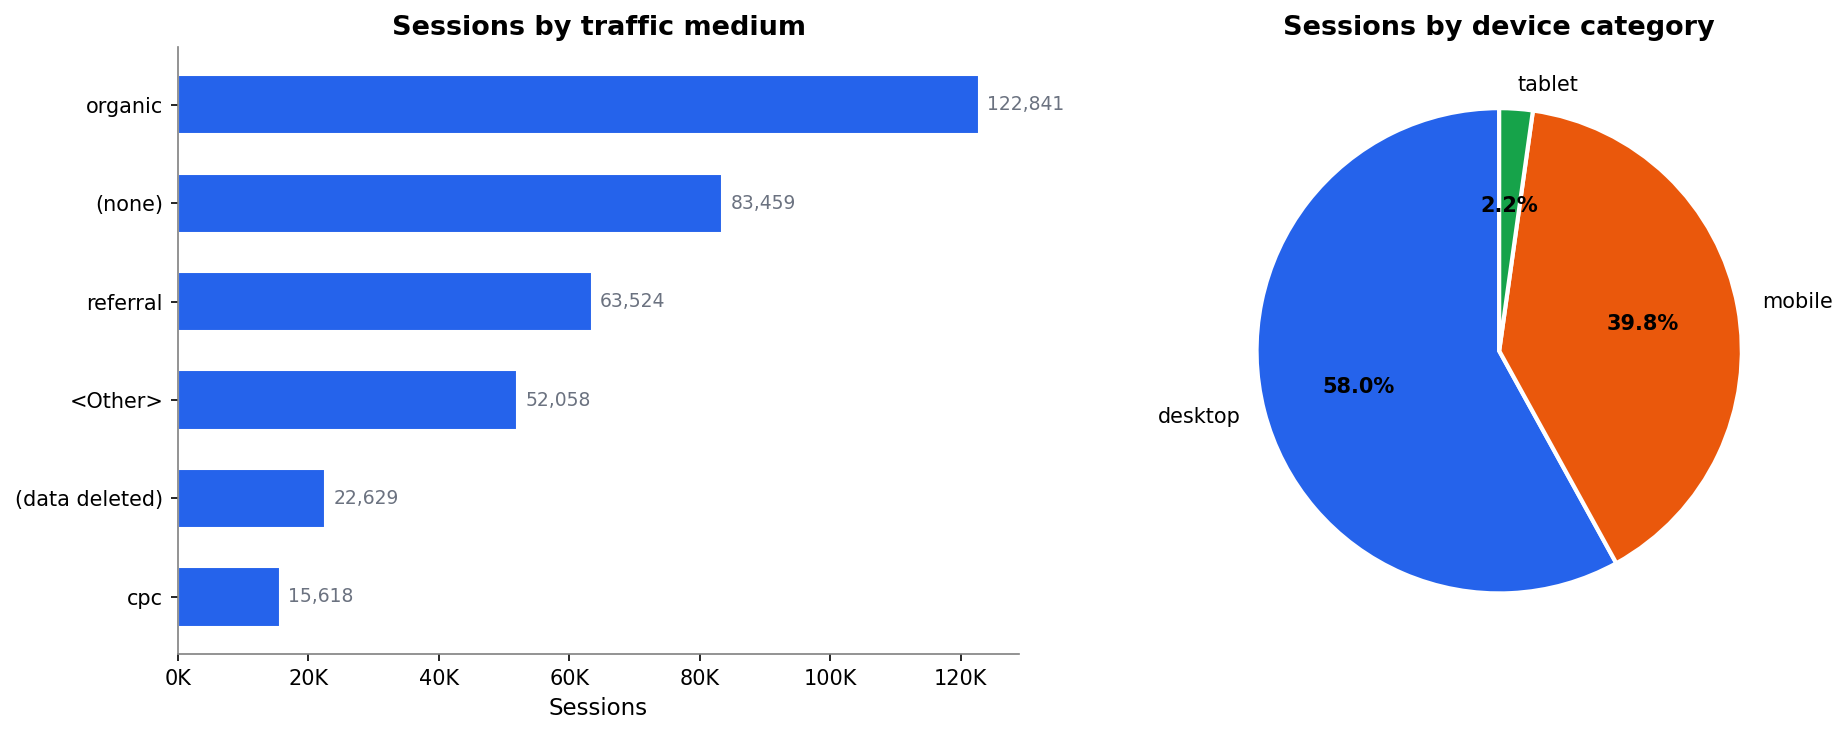

In [12]:
# ── Chart: traffic medium vs device (side by side) ────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# — Traffic medium —
top_mediums = sessions['traffic_medium'].value_counts().head(8)
ax1.barh(top_mediums.index, top_mediums.values, color=BLUE, edgecolor='white', height=0.6)
ax1.invert_yaxis()
ax1.set_title('Sessions by traffic medium', fontweight='bold')
ax1.set_xlabel('Sessions')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
for bar, val in zip(ax1.patches, top_mediums.values):
    ax1.text(val + top_mediums.max() * 0.01,
             bar.get_y() + bar.get_height() / 2,
             f'{val:,}', va='center', fontsize=9, color=GRAY)

# — Device —
device_vc = sessions['device'].value_counts()
wedge_colors = [BLUE, ORANGE, GREEN]
wedges, texts, autotexts = ax2.pie(
    device_vc.values,
    labels=device_vc.index,
    autopct='%1.1f%%',
    colors=wedge_colors[:len(device_vc)],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
ax2.set_title('Sessions by device category', fontweight='bold')

plt.tight_layout()
plt.savefig('reports/fig_traffic_device.png', bbox_inches='tight')
plt.show()

## Traffic medium counts
 
> * `organic` is the dominant acquisition channel with **122,841 sessions (34%)**, followed by `(none)` — direct / unattributed traffic — at 83,459. `<Other>` (52,058) and `(data deleted)` (22,629) are obfuscation artefacts from the GA4 public dataset, not real medium values. Together, the six medium categories are compact enough for straightforward one-hot encoding in NB-03 with no grouping required.
> * The device split shows `desktop` dominates at roughly **58% of sessions**, with `mobile` at ~40% and `tablet` under 3%. This desktop-heavy profile is consistent with a B2C merchandise store where purchase decisions involve comparison and higher cart values — behaviour more typical of desktop browsing. The relative parity between desktop and mobile makes device a useful feature for the model, as the CVR table below confirms the two behave differently.
 

In [22]:
# ── Conversion rate by traffic medium ─────────────────────────────────────────
cvr_medium = (
    sessions
    .groupby('traffic_medium')
    .agg(sessions_n=('converted', 'count'),
         conversions=('converted', 'sum'))
    .assign(cvr=lambda df: df.conversions / df.sessions_n * 100)
    .sort_values('cvr', ascending=False)
    .reset_index()
)
print('Conversion rate by traffic medium:')
print(cvr_medium.to_string(index=False))

Conversion rate by traffic medium:
traffic_medium  sessions_n  conversions      cvr
(data deleted)       22629          707 3.124310
      referral       63524         1056 1.662364
        (none)       83459         1079 1.292850
       organic      122841         1347 1.096539
           cpc       15618          153 0.979639
       <Other>       52058          506 0.971993


### CVR by traffic medium table
 
> `(data deleted)` sessions convert at **3.1%** — more than double the overall rate of 1.35%. This channel likely contains paid or affiliate traffic whose UTM parameters were removed during obfuscation. `referral` converts at 1.66%, above `organic` (1.10%) and `CPC` (0.98%). The low CPC conversion rate relative to its paid nature suggests either poor landing-page fit or that the obfuscation has misclassified some CPC sessions. These channel-level CVR differences are meaningful signals — `traffic_medium` is a strong candidate feature for the model.

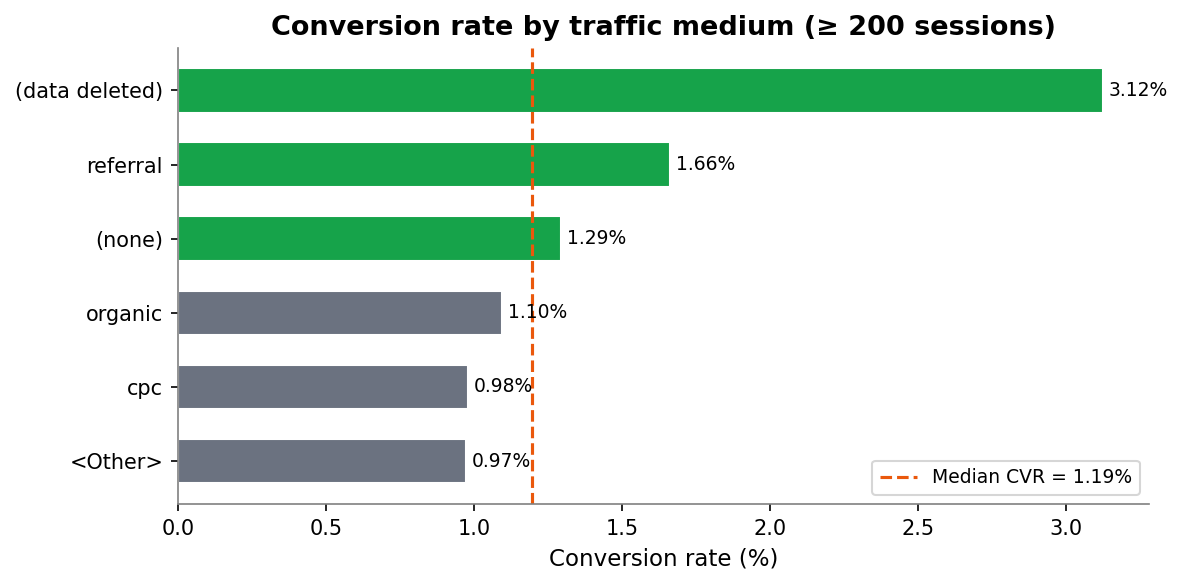

In [23]:
# ── Chart: CVR by traffic medium ──────────────────────────────────────────────
# Filter to mediums with at least 200 sessions for a stable rate
cvr_plot = cvr_medium[cvr_medium['sessions_n'] >= 200].copy()

fig, ax = plt.subplots(figsize=(8, 4))
colors_bar = [GREEN if v >= cvr_plot['cvr'].median() else GRAY for v in cvr_plot['cvr']]
ax.barh(cvr_plot['traffic_medium'], cvr_plot['cvr'],
        color=colors_bar, edgecolor='white', height=0.6)
ax.invert_yaxis()
ax.set_xlabel('Conversion rate (%)')
ax.set_title('Conversion rate by traffic medium (≥ 200 sessions)', fontweight='bold')
ax.axvline(cvr_plot['cvr'].median(), color=ORANGE, linestyle='--',
           linewidth=1.5, label=f"Median CVR = {cvr_plot['cvr'].median():.2f}%")
ax.legend(fontsize=9)
for bar, val in zip(ax.patches, cvr_plot['cvr']):
    ax.text(val + 0.02, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('reports/fig_cvr_by_medium.png', bbox_inches='tight')
plt.show()

### CVR by traffic medium chart
 
> The chart reinforces the table: `(data deleted)` and `referral` are the two above-median channels, while `organic`, `cpc`, and `<Other>` cluster near or below the median. For the model, the distinction between `referral` and `organic` traffic is worth preserving explicitly rather than grouping into a catch-all bucket.

In [24]:
# ── Conversion rate by device ──────────────────────────────────────────────────
cvr_device = (
    sessions
    .groupby('device')
    .agg(sessions_n=('converted', 'count'),
         conversions=('converted', 'sum'))
    .assign(cvr=lambda df: df.conversions / df.sessions_n * 100)
    .sort_values('cvr', ascending=False)
    .reset_index()
)
print('Conversion rate by device:')
print(cvr_device.to_string(index=False))

Conversion rate by device:
 device  sessions_n  conversions      cvr
 mobile      143185         1995 1.393302
desktop      208942         2749 1.315676
 tablet        8002          104 1.299675


### CVR by device table
 
> Conversion rates are remarkably similar across devices — **mobile 1.39%, desktop 1.32%, tablet 1.30%** — with differences of less than 0.1 percentage point. This near-parity suggests that device type is a weak standalone predictor of conversion for this store. It will still be included as a model feature (encoding is low-cost and tree models can find interaction effects), but we should not expect it to appear prominently in SHAP importance rankings.

---
## 6. Geographic distribution

In [25]:
# ── Top 15 countries by session volume ────────────────────────────────────────
top_countries = sessions['country'].value_counts().head(15)
print('Top 15 countries by session count:')
print(top_countries.to_string())

Top 15 countries by session count:
country
United States     158155
India              33769
Canada             26824
United Kingdom     11327
France              7162
Spain               6667
Germany             6393
China               6258
Taiwan              6057
Italy               4998
Singapore           4741
Japan               4732
South Korea         4523
Netherlands         4073
Turkey              3646


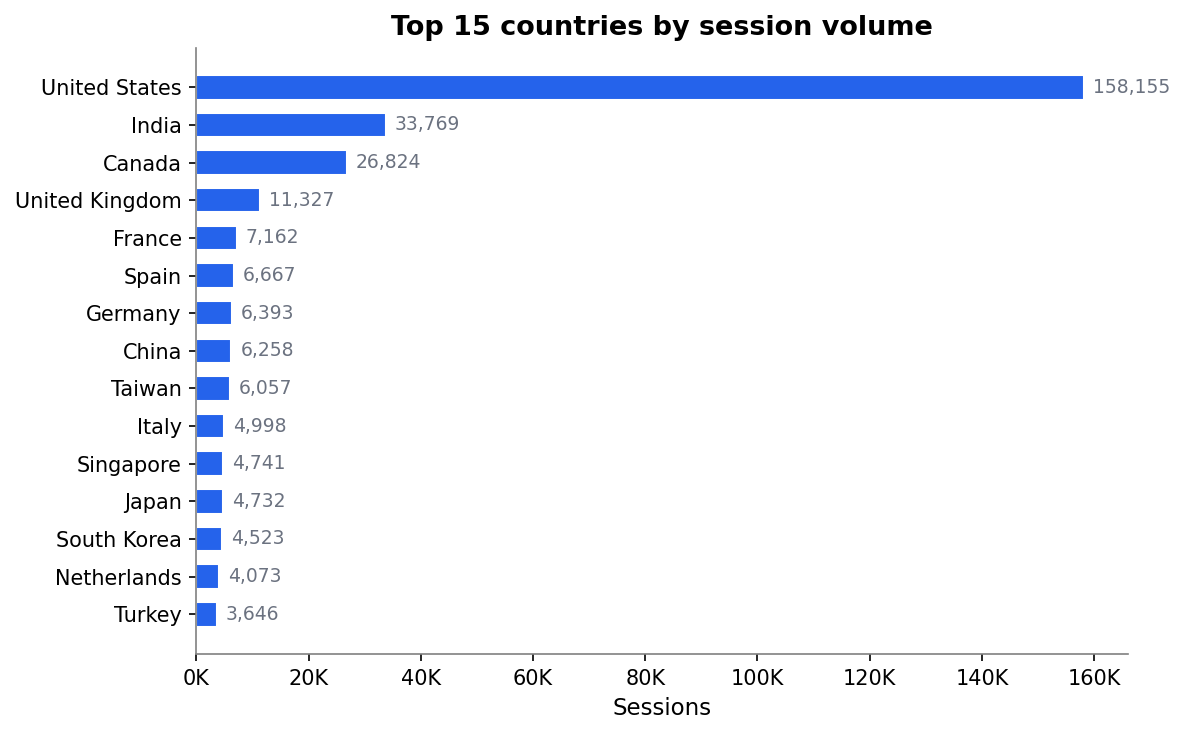

In [36]:
# ── Chart: top countries ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_countries.index[::-1], top_countries.values[::-1],
        color=BLUE, edgecolor='white', height=0.65)
ax.set_xlabel('Sessions')
ax.set_title('Top 15 countries by session volume', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
for bar, val in zip(ax.patches, top_countries.values[::-1]):
    ax.text(val + top_countries.max() * 0.01,
            bar.get_y() + bar.get_height()/2,
            f'{val:,}', va ='center', fontsize = 9, color = GRAY)
plt.tight_layout()
plt.savefig('reports/fig_top_countries.png', bbox_inches='tight')
plt.show()

### Top 15 countries chart
 
> The **United States accounts for 43.9% of all sessions** (158,155 of 360,129), dwarfing every other market. India (9.4%) and Canada (7.5%) are distant second and third. The long tail of 109 countries means that encoding country naively would create a 109-column sparse matrix; in NB-03 the top 10 countries will be retained as explicit levels, with the remaining 99 collapsed into an `other` category.

In [43]:
# ── Conversion rate: top 10 countries (min 1,000 sessions) ────────────────────
cvr_country = (
    sessions
    .groupby('country')
    .agg(sessions_n=('converted', 'count'),
         conversions=('converted', 'sum'))
    .query('sessions_n >= 1000')
    .assign(cvr=lambda df: df.conversions / df.sessions_n * 100)
    .sort_values('cvr', ascending=False)
    .head(10)
    .reset_index()
)
print('Top-converting countries (≥ 1,000 sessions):')
print(cvr_country[['country', 'sessions_n', 'conversions', 'cvr']].to_string(index=False))

Top-converting countries (≥ 1,000 sessions):
    country  sessions_n  conversions      cvr
   Colombia        1701           31 1.822457
     Russia        2336           40 1.712329
   Thailand        1586           27 1.702396
   Malaysia        1872           31 1.655983
      Japan        4732           76 1.606086
     Poland        3142           50 1.591343
     Greece        1337           21 1.570681
     Brazil        3596           55 1.529477
Netherlands        4073           61 1.497668
  Hong Kong        2208           33 1.494565


### top-converting countries table
 
> The highest-converting countries (Colombia 1.82%, Russia 1.71%, Thailand 1.70%) are all mid-tier volume markets — none appear in the top 15 by session count. This is a common pattern: large-volume markets (US, India) have more casual, research-oriented visitors, while smaller markets contain a higher proportion of purchase-ready users. The US — despite its volume dominance — likely sits near or below the overall 1.35% CVR. This motivates including country as a model feature rather than relying solely on volume-weighted signals.

---
## 7. Purchase funnel drop-off

Using `events_sample.csv`, count unique sessions that reached each funnel stage.  
A session "reaches" a stage if it contains at least one event of that type.

In [44]:
# ── Build session-level funnel flags ──────────────────────────────────────────
# We need a unique session key: user_pseudo_id + session_id
events_raw['session_key'] = (
    events_raw['user_pseudo_id'].astype(str) + '_' +
    events_raw['session_id'].astype(str)
)

funnel_steps = ['view_item', 'add_to_cart', 'begin_checkout', 'purchase']

# For each step, count distinct sessions that had that event
funnel_sessions = {}
for step in funnel_steps:
    mask = events_raw['event_name'] == step
    funnel_sessions[step] = events_raw.loc[mask, 'session_key'].nunique()

funnel_df = pd.DataFrame([
    {'stage': s, 'sessions': funnel_sessions[s]}
    for s in funnel_steps
])
funnel_df['pct_of_top'] = (funnel_df['sessions'] / funnel_df['sessions'].iloc[0] * 100).round(1)
funnel_df['step_dropoff_pct'] = (
    (1 - funnel_df['sessions'] / funnel_df['sessions'].shift(1)) * 100
).round(1)

print('Purchase funnel:')
print(funnel_df.to_string(index=False))

Purchase funnel:
         stage  sessions  pct_of_top  step_dropoff_pct
     view_item     77020       100.0               NaN
   add_to_cart     15188        19.7              80.3
begin_checkout     11106        14.4              26.9
      purchase      4848         6.3              56.3


### Funnel table
 
> The sharpest drop in the funnel occurs at the **view item → add to cart** step, where **80.3% of sessions that viewed a product did not add anything to the cart**. This is the widest gap in the funnel and the strongest signal that intent, not discovery, is the primary conversion barrier. Of sessions that do add to cart, 26.9% drop off before checkout — a secondary friction point. The final step (checkout → purchase) loses another 56.3%, which is typical for ecommerce checkouts and may reflect guest-checkout friction or payment abandonment. The `add_to_cart` and `checkout_starts` counts will be the most predictive raw features in the model, and the derived `cart_to_view_ratio` will capture this funnel efficiency at the session level.

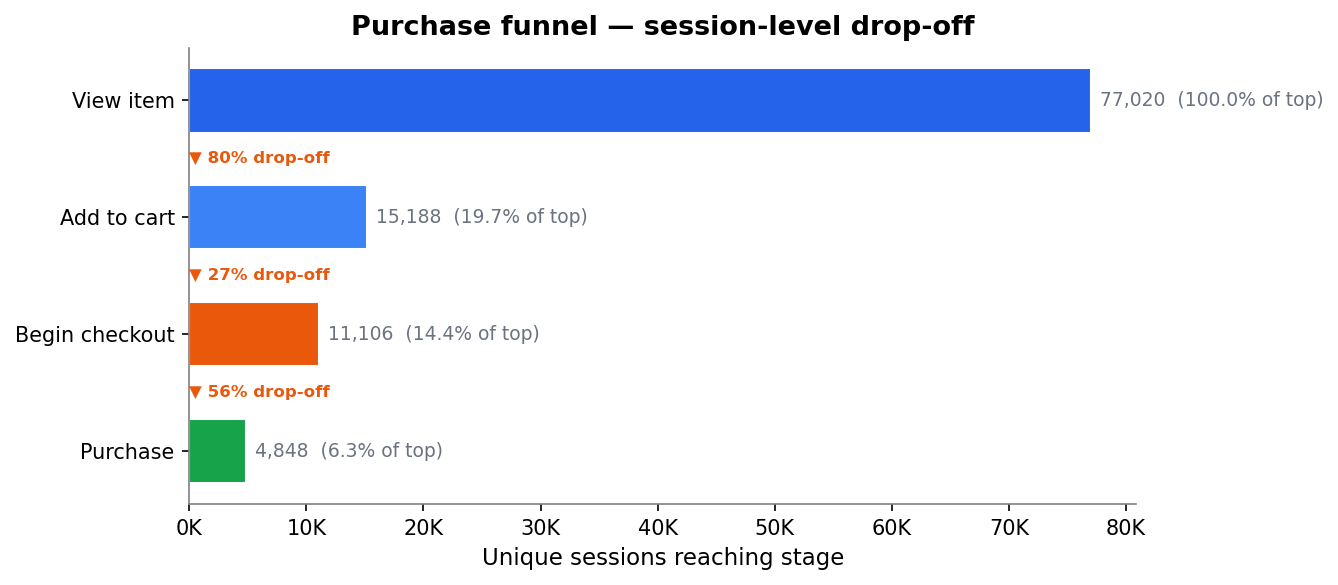

In [53]:
# ── Chart: funnel drop-off ─────────────────────────────────────────────────────
stage_labels = {
    'view_item':      'View item',
    'add_to_cart':    'Add to cart',
    'begin_checkout': 'Begin checkout',
    'purchase':       'Purchase',
}
funnel_df['label'] = funnel_df['stage'].map(stage_labels)

fig, ax = plt.subplots(figsize=(9, 4))
bar_colors = [BLUE, '#3B82F6', ORANGE, GREEN]
bars = ax.barh(
    funnel_df['label'][::-1],
    funnel_df['sessions'][::-1],
    color=bar_colors[::-1],
    edgecolor='white',
    height=0.55,
)

for bar, (_, row) in zip(bars, funnel_df[::-1].iterrows()):
    n_label = f"{row['sessions']:,}  ({row['pct_of_top']:.1f}% of top)"
    ax.text(
        bar.get_width() + funnel_df['sessions'].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        n_label, va='center', fontsize=9, color=GRAY,
    )

# Drop-off annotations (between bars)
for i, (_, row) in enumerate(funnel_df.iloc[1:].iterrows(), start=1):
    drop = row['step_dropoff_pct']
    ax.annotate(
        f'▼ {drop:.0f}% drop-off',
        xy=(0, len(funnel_df) - i - 0.5),
        xycoords=('data', 'data'),
        fontsize=8, color=ORANGE, fontweight='bold',
        ha='left', va='center',
    )

ax.set_xlabel('Unique sessions reaching stage')
ax.set_title('Purchase funnel — session-level drop-off', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
plt.tight_layout()
plt.savefig('reports/fig_funnel_dropoff.png', bbox_inches='tight')
plt.show()

### Funnel chart
 
> The horizontal bar chart makes the asymmetry viscerally clear: the purchase bar is less than 7% the width of the view-item bar. From a business perspective, retargeting campaigns should prioritise the **view-item → add-to-cart gap** — users who viewed products but did not add to cart represent the largest recoverable audience. This is the core use case for the propensity model built in NB-04.

---
## 8. Class imbalance — conversion rate

This is the single most important fact for model design decisions.

In [54]:
# ── Overall conversion rate ────────────────────────────────────────────────────
n_total      = len(sessions)
n_converted  = sessions['converted'].sum()
n_non        = n_total - n_converted
cvr_overall  = n_converted / n_total * 100
imbalance_ratio = n_non / n_converted

print(f'Total sessions   : {n_total:>10,}')
print(f'Converted (1)    : {n_converted:>10,}  ({cvr_overall:.2f}%)')
print(f'Not converted (0): {n_non:>10,}  ({100-cvr_overall:.2f}%)')
print(f'Imbalance ratio  : {imbalance_ratio:.1f}:1  (non-converted : converted)')
print()
print(f'→ XGBoost scale_pos_weight = {imbalance_ratio:.1f}')
print(f'→ Logistic Regression / Random Forest: class_weight="balanced"')

Total sessions   :    360,129
Converted (1)    :      4,848  (1.35%)
Not converted (0):    355,281  (98.65%)
Imbalance ratio  : 73.3:1  (non-converted : converted)

→ XGBoost scale_pos_weight = 73.3
→ Logistic Regression / Random Forest: class_weight="balanced"


### Class imbalance stats
 
> The dataset is heavily imbalanced: **only 4,848 sessions converted (1.35%)** against 355,281 that did not — a **73:1 ratio**. This has direct consequences for modelling:
 
- A naive classifier that always predicts "no purchase" would achieve 98.65% accuracy — making accuracy a useless metric.
- **PR-AUC** (precision-recall area under curve) is the primary evaluation metric in NB-04 because it focuses exclusively on the model's ability to identify the minority (converted) class.
- `scale_pos_weight = 73.3` will be passed to XGBoost to compensate for the imbalance during training.

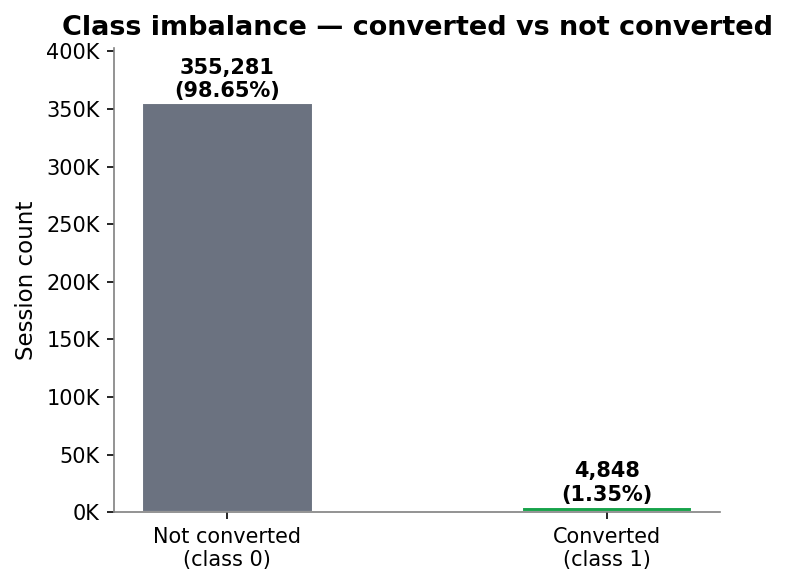

In [56]:
# ── Chart: class imbalance ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
classes = ['Not converted\n(class 0)', 'Converted\n(class 1)']
counts  = [n_non, n_converted]
colors_bar = [GRAY, GREEN]
bars = ax.bar(classes, counts, color=colors_bar, edgecolor='white', width=0.45)

for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + n_total * 0.005,
            f'{val:,}\n({val/n_total*100:.2f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Session count')
ax.set_title('Class imbalance — converted vs not converted', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
ax.set_ylim(0, n_total * 1.12)
plt.tight_layout()
plt.savefig('reports/fig_class_imbalance.png', bbox_inches='tight')
plt.show()

### Class imbalance chart
 
> The visual confirms what the numbers already tell us: the converted bar is barely visible at this scale. Any model evaluation that does not account for this imbalance will produce misleading results. For the retargeting use case, a model with high precision on the positive class — even at the cost of some recall — is preferable to one that flags too many non-converters as targets.
 

---
## 9. Correlation heatmap

Examine linear correlations between numeric features, and between features and the `converted` label.

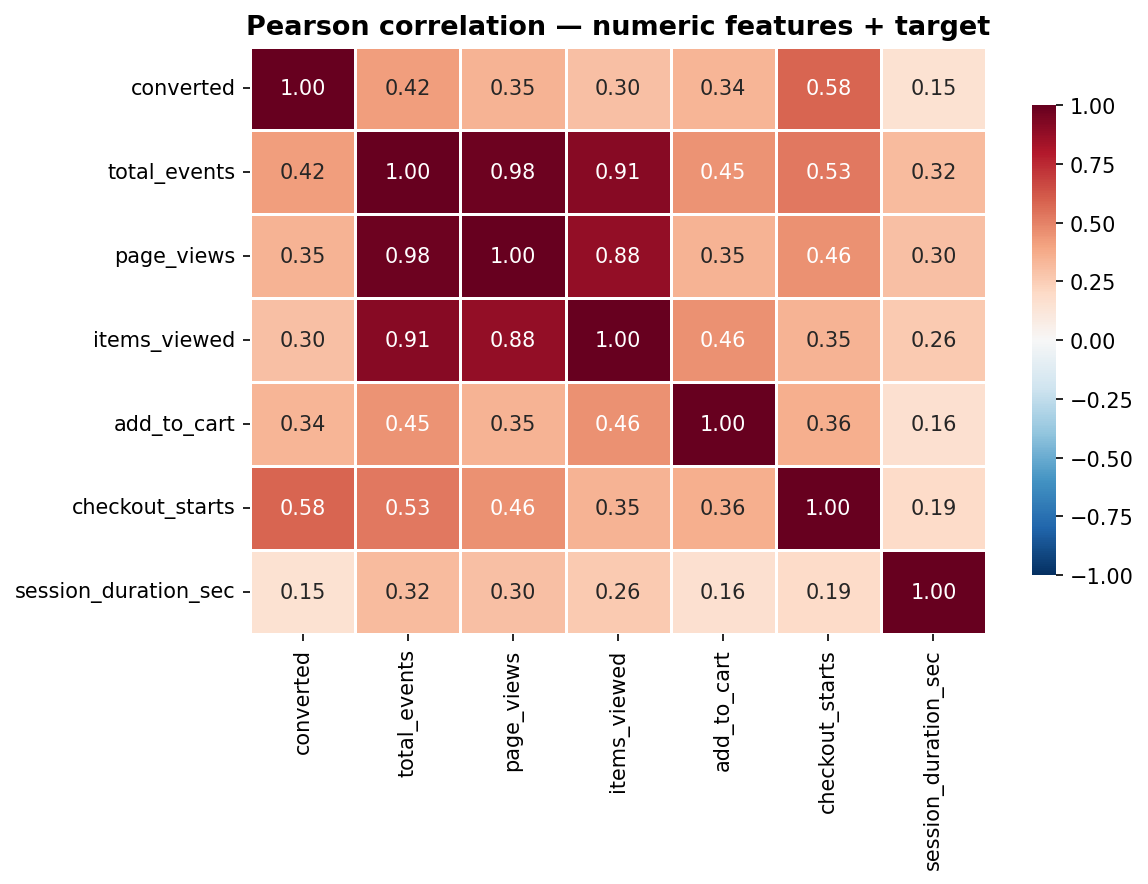

In [57]:
# ── Correlation matrix ────────────────────────────────────────────────────────
numeric_cols = ['converted', 'total_events', 'page_views', 'items_viewed',
                'add_to_cart', 'checkout_starts', 'session_duration_sec']

corr = sessions[numeric_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)   # upper triangle only for mirror

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'shrink': 0.8},
)
ax.set_title('Pearson correlation — numeric features + target', fontweight='bold')
plt.tight_layout()
plt.savefig('reports/fig_correlation_heatmap.png', bbox_inches='tight')
plt.show()

In [58]:
# ── Target correlation ranking ─────────────────────────────────────────────────
target_corr = (
    corr['converted']
    .drop('converted')
    .abs()
    .sort_values(ascending=False)
)
print('Feature correlation with `converted` (absolute Pearson r):')
print(target_corr.to_string())
print()
print('Note: These are linear correlations only.')
print('Tree-based models will capture non-linear relationships missed here.')

Feature correlation with `converted` (absolute Pearson r):
checkout_starts         0.58
total_events            0.42
page_views              0.35
add_to_cart             0.34
items_viewed            0.30
session_duration_sec    0.15

Note: These are linear correlations only.
Tree-based models will capture non-linear relationships missed here.


### Correlation ranking
 
> `checkout_starts` has by far the strongest linear correlation with `converted` (r = 0.58), which makes intuitive sense — a session that started checkout is almost by definition close to converting. `total_events` (0.42) and `page_views` (0.35) follow, reflecting general engagement depth. `session_duration_sec` has the weakest correlation (0.15), consistent with our outlier findings: raw duration is noisy and a poor proxy for intent without normalisation. 
 
> The moderate correlation values overall suggest the relationship between features and conversion is **non-linear**, which is why the tree-based models (Random Forest, XGBoost) are expected to outperform Logistic Regression — they can capture interaction effects such as "high checkout_starts AND high items_viewed" that a linear model must approximate with manual feature crosses.

---
## 10. EDA summary & notes for NB-03

### Key findings

In [59]:
# ── Print a clean summary to carry into NB-03 ─────────────────────────────────
print('=' * 65)
print('EDA SUMMARY — Key findings')
print('=' * 65)

print(f"""
DATASET SIZE
  Sessions (sessions.csv)   : {len(sessions):,} rows
  Events (events_sample.csv): {len(events_raw):,} rows

CONVERSION
  Overall CVR               : {cvr_overall:.2f}%
  Imbalance ratio           : ~{imbalance_ratio:.0f}:1  → use scale_pos_weight in XGBoost

DISTRIBUTIONS
  All numeric features are heavily right-skewed.
  Many sessions have 0 cart events and 0 item views.
  session_duration_sec has extreme outliers (check 99th pct above).

CATEGORICAL FEATURES
  device        : {sessions['device'].nunique()} unique values  
  traffic_medium: {sessions['traffic_medium'].nunique()} unique values → one-hot encode top categories
  traffic_source: {sessions['traffic_source'].nunique()} unique values → many sparse; likely drop or group
  country       : {sessions['country'].nunique()} unique values → top-N encode (keep top 10)

DATA QUALITY
  sessions.csv : {sessions.isna().any().sum()} columns with nulls
  Check for '<Other>' placeholder values in country / source fields.

NOTES FOR NB-03 FEATURE ENGINEERING
  1. Cap extreme outliers in session_duration_sec at 99th percentile.
  2. Create cart_to_view_ratio and checkout_to_cart_ratio with zero-div guard.
  3. Label-encode device (desktop=0, mobile=1, tablet=2).
  4. One-hot encode traffic_medium top categories + 'other' bucket.
  5. Top-10 country encoding; remaining → 'other'.
  6. Consider log1p transform for tree models (less critical, but useful for LR baseline).
""")
print('=' * 65)

EDA SUMMARY — Key findings

DATASET SIZE
  Sessions (sessions.csv)   : 360,129 rows
  Events (events_sample.csv): 2,194,458 rows

CONVERSION
  Overall CVR               : 1.35%
  Imbalance ratio           : ~73:1  → use scale_pos_weight in XGBoost

DISTRIBUTIONS
  All numeric features are heavily right-skewed.
  Many sessions have 0 cart events and 0 item views.
  session_duration_sec has extreme outliers (check 99th pct above).

CATEGORICAL FEATURES
  device        : 3 unique values  
  traffic_medium: 6 unique values → one-hot encode top categories
  traffic_source: 5 unique values → many sparse; likely drop or group
  country       : 109 unique values → top-N encode (keep top 10)

DATA QUALITY
  sessions.csv : 0 columns with nulls
  Check for '<Other>' placeholder values in country / source fields.

NOTES FOR NB-03 FEATURE ENGINEERING
  1. Cap extreme outliers in session_duration_sec at 99th percentile.
  2. Create cart_to_view_ratio and checkout_to_cart_ratio with zero-div guard.
 

---

### Data quality notes

The GA4 obfuscated dataset contains placeholder values (`<Other>`, `(none)`, `(direct)`) in categorical fields. These are **expected** — they reflect:

- **Obfuscation by design:** Certain values are masked to protect user privacy.
- **Direct / unattributed traffic:** Sessions where no UTM parameters were set.

These will be treated as valid categorical levels in NB-03 (not imputed or dropped).

---

### Charts saved

| File | Description |
|---|---|
| `reports/fig_event_taxonomy.png` | Event counts by type |
| `reports/fig_session_distributions.png` | 2×3 histogram grid of numeric features |
| `reports/fig_traffic_device.png` | Traffic medium + device pie |
| `reports/fig_cvr_by_medium.png` | Conversion rate by traffic medium |
| `reports/fig_top_countries.png` | Top 15 countries by volume |
| `reports/fig_funnel_dropoff.png` | Purchase funnel drop-off |
| `reports/fig_class_imbalance.png` | Converted vs not converted |
| `reports/fig_correlation_heatmap.png` | Pearson correlation matrix |

---

*NB-02 complete. Proceed to NB-03 feature engineering.*